# **02 LangGraph 필수 구성요소**

### 학습 내용
1. LangGraph의 핵심 개념 이해
2. State (상태) 정의 방법
3. TypedDict와 Pydantic BaseModel 이해
4. Reducer 함수 사용법
5. 간단한 그래프 구성

## 1. LangGraph란?

**LangGraph**는 상태 기반의 멀티 액터 애플리케이션을 구축하기 위한 프레임워크입니다.

https://docs.langchain.com/oss/python/langgraph/overview

### 핵심 구성 요소

1. **State (상태)** - 그래프가 관리하는 데이터
2. **Node (노드)** - 상태를 변경하는 함수
3. **Edge (엣지)** - 노드 간의 연결
4. **Graph (그래프)** - 전체 워크플로우

### LangGraph의 장점

| 특징 | 설명 |
|-----|------|
| 시각화 | 복잡한 AI 워크플로우를 시각적으로 구성 |
| 상태 관리 | 상태 관리가 명확하고 추적 가능 |
| 조건 분기 | 조건부 분기와 반복 처리 지원 |
| 디버깅 | 디버깅과 추적이 용이함 |

## 2. TypedDict 이해하기

Python의 `TypedDict`는 딕셔너리의 키와 값의 타입을 명시할 수 있습니다.

### 2-1. TypedDict 기본 사용법

TypedDict는 타입 힌트만 제공하며, 런타임 검증은 수행하지 않습니다.

In [1]:
from typing_extensions import TypedDict

class User(TypedDict):
    id: int
    name: str
    email: str

# 올바른 타입의 데이터
user1: User = {
    'id': 1,
    'name': 'nayeon_park',
    'email': 'uoahvu@gmail.com'
}
print("User 1:", user1)

User 1: {'id': 1, 'name': 'nayeon_park', 'email': 'uoahvu@gmail.com'}


In [2]:
# 잘못된 타입을 사용해도 런타임에는 에러가 발생하지 않습니다
# (TypedDict는 타입 힌트일 뿐, 런타임 검증을 하지 않음)
user2: User = {
    'id': 1,
    'name': 123,  # 숫자인데도 실행됨
    'email': 'uoahvu@gmail.com'
}
print("User 2:", user2)

User 2: {'id': 1, 'name': 123, 'email': 'uoahvu@gmail.com'}


## 3. Pydantic BaseModel 이해하기

`Pydantic`의 `BaseModel`은 런타임에 타입을 검증하고, 자동 변환도 수행합니다.

In [3]:
from pydantic import BaseModel, ValidationError

class User(BaseModel):
    id: int
    name: str
    email: str

# 올바른 데이터
user_data = {
    'id': 1,
    'name': 'nayeon_park',
    'email': 'uoahvu@gmail.com'
}

user1 = User(**user_data)
print("User 1:", user1)
print("타입:", type(user1))

User 1: id=1 name='nayeon_park' email='uoahvu@gmail.com'
타입: <class '__main__.User'>


In [4]:
# 자동 타입 변환
user_data2 = {
    'id': '2',  # 문자열이지만 int로 자동 변환됨
    'name': 'nayeon_park',
    'email': 'uoahvu@gmail.com'
}

user2 = User(**user_data2)
print("User 2:", user2)
print("ID 타입:", type(user2.id))  # int로 변환됨

User 2: id=2 name='nayeon_park' email='uoahvu@gmail.com'
ID 타입: <class 'int'>


In [5]:
# 변환 불가능한 타입이면 오류 발생
try:
    user_data3 = {
        'id': 'abc',  # 변환 불가능
        'name': 'nayeon_park',
        'email': 'uoahvu@gmail.com'
    }
    user3 = User(**user_data3)
except ValidationError as e:
    print("❌ ValidationError 발생:")
    print(e)

❌ ValidationError 발생:
1 validation error for User
id
  Input should be a valid integer, unable to parse string as an integer [type=int_parsing, input_value='abc', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/int_parsing


### TypedDict vs Pydantic BaseModel

| 구분 | TypedDict | Pydantic BaseModel |
|-----|-----------|-------------------|
| 타입 검증 | 정적 분석만 (실행 시 검증 없음) | 런타임 검증 |
| 타입 변환 | 없음 | 자동 변환 |
| 사용 시기 | 간단한 타입 힌트 | 데이터 검증이 필요한 경우 |
| 성능 | 빠름 | 약간 느림 (검증 오버헤드) |

## 4. State - Graph Schema 지정하기

LangGraph에서 **State**는 그래프의 스키마와 업데이트 방법을 정의합니다.

- **그래프 스키마**: 어떤 데이터를 관리할지 정의
- **리듀서 함수**: 업데이트를 어떻게 적용할지 정의

In [6]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

# 입력을 위한 스키마 정의
class InputState(TypedDict):
    question: str

# 출력을 위한 스키마 정의
class OutputState(TypedDict):
    answer: str

# 입력과 출력을 합한 종합 스키마 정의
class OverallState(InputState, OutputState):
    pass

In [7]:
# 입력을 처리하고 답변을 생성하는 노드 정의
def answer_node(state: InputState):
    question = state["question"]

    # 간단한 인사 응답 로직
    if "안녕" in question or "hi" in question.lower():
        answer = "안녕하세요! 무엇을 도와드릴까요?"
    else:
        answer = "질문을 이해하지 못했습니다."

    return {"answer": answer}

# 그래프 생성
graph_builder = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)
graph_builder.add_node("answer_node", answer_node)
graph_builder.add_edge(START, "answer_node")
graph_builder.add_edge("answer_node", END)
graph = graph_builder.compile()

In [8]:
question = "안녕하세요."
result = graph.invoke({"question": question})
print("입력:", {"question": question})
print("출력:", result)

입력: {'question': '안녕하세요.'}
출력: {'answer': '안녕하세요! 무엇을 도와드릴까요?'}


## 5. Reducer 이해하기 - 기본 동작

**Reducer**가 지정되지 않으면, 노드의 반환값이 기존 상태를 **완전히 덮어씁니다**.

In [9]:
from typing_extensions import TypedDict

class State(TypedDict):
    value1: int
    value2: list[str]

def node_a(state: State):
    print(f"Node A - 현재 상태: {state}")
    # value1만 업데이트 (value2는 영향 없음)
    return {"value1": 100}

def node_b(state: State):
    print(f"Node B - 현재 상태: {state}")
    # value2를 새 리스트로 덮어쓰기
    return {"value2": ["새로운", "리스트"]}

# 그래프 구성
graph_builder = StateGraph(State)
graph_builder.add_node("node_a", node_a)
graph_builder.add_node("node_b", node_b)

graph_builder.add_edge(START, "node_a")
graph_builder.add_edge("node_a", "node_b")
graph_builder.add_edge("node_b", END)
graph = graph_builder.compile()

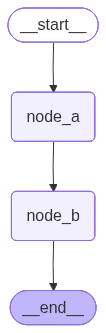

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [11]:
initial_state = {"value1": 1, "value2": ["초기", "값"]}
result = graph.invoke(initial_state)
print("\n최종 결과:", result)

Node A - 현재 상태: {'value1': 1, 'value2': ['초기', '값']}
Node B - 현재 상태: {'value1': 100, 'value2': ['초기', '값']}

최종 결과: {'value1': 100, 'value2': ['새로운', '리스트']}


## 6. Reducer 지정하기 - operator.add

**Reducer**를 지정하면 업데이트 방식을 제어할 수 있습니다.

### 6-1. 리듀서 함수 직접 만들기

In [12]:
def add_values(x: int, y: int) -> int:
    return x + y

def add_lists(x: list[str], y: list[str]) -> list[str]:
    return x + y

In [13]:
from typing import Annotated
from typing_extensions import TypedDict

class State(TypedDict):
    value1: Annotated[int, add_values]  # 숫자 더하기
    value2: Annotated[list[str], add_lists]  # 리스트 연결

def node_a(state: State):
    print(f"Node A - 현재 상태: {state}")
    return {"value1": 10, "value2": ["A"]}

def node_b(state: State):
    print(f"Node B - 현재 상태: {state}")
    return {"value1": 20, "value2": ["B", "C"]}

# 그래프 구성
graph_builder = StateGraph(State)
graph_builder.add_node("node_a", node_a)
graph_builder.add_node("node_b", node_b)
graph_builder.add_edge(START, "node_a")
graph_builder.add_edge("node_a", "node_b")
graph_builder.add_edge("node_b", END)
graph = graph_builder.compile()

In [14]:
initial_state = {"value1": 5, "value2": ["초기"]}
result = graph.invoke(initial_state)
print("최종 결과:", result)

Node A - 현재 상태: {'value1': 5, 'value2': ['초기']}
Node B - 현재 상태: {'value1': 15, 'value2': ['초기', 'A']}
최종 결과: {'value1': 35, 'value2': ['초기', 'A', 'B', 'C']}


### 6-2. `operator.add`를 리듀서 함수로 활용하기

`operator.add`를 사용하면 기존 값에 **더하기** 연산이 적용됩니다.

### operator.add 동작 방식

| 데이터 타입 | operator.add 동작 | 예시 |
|-----------|------------------|------|
| int, float | 숫자 덧셈 | 5 + 10 = 15 |
| list | 리스트 연결 | [1, 2] + [3] = [1, 2, 3] |
| str | 문자열 연결 | "hello" + " world" |

In [15]:
from operator import add

class State(TypedDict):
    value1: Annotated[int, add]  # 숫자 더하기
    value2: Annotated[list[str], add]  # 리스트 연결

In [16]:
def node_a(state: State):
    print(f"Node A - 현재 상태: {state}")
    return {"value1": 10, "value2": ["A"]}

def node_b(state: State):
    print(f"Node B - 현재 상태: {state}")
    return {"value1": 20, "value2": ["B", "C"]}

# 그래프 구성
graph_builder = StateGraph(State)
graph_builder.add_node("node_a", node_a)
graph_builder.add_node("node_b", node_b)
graph_builder.add_edge(START, "node_a")
graph_builder.add_edge("node_a", "node_b")
graph_builder.add_edge("node_b", END)
graph = graph_builder.compile()

In [17]:
initial_state = {"value1": 5, "value2": ["초기"]}
result = graph.invoke(initial_state)
print("최종 결과:", result)

Node A - 현재 상태: {'value1': 5, 'value2': ['초기']}
Node B - 현재 상태: {'value1': 15, 'value2': ['초기', 'A']}
최종 결과: {'value1': 35, 'value2': ['초기', 'A', 'B', 'C']}


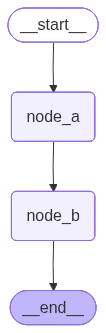

In [18]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### 📖 과제 1: 간단한 카운터 그래프 만들기

다음 요구사항을 만족하는 그래프를 만들어보세요:

**요구사항**:
1. State에 `count`(int)와 `history`(list[str]) 필드 정의
2. `increment` 노드: count를 1 증가시키고, history에 "숫자 증가!" 추가
3. `decrement` 노드: count를 1 감소시키고, history에 "숫자 감소!" 추가
4. 실행 순서: START → increment → decrement → END
5. 초기값: count=0, history=[]

**힌트**: 
- Reducer로 `add`를 사용하세요
- count는 숫자 덧셈, history는 리스트 연결

**예상 출력**:
```python
# 최종 결과: {"count": 0, "history": ["숫자 증가!", "숫자 감소!"]}
```

In [15]:
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END

# TODO: State 정의

# TODO: increment 노드 구현

# TODO: decrement 노드 구현

# TODO: 그래프 구성

# TODO: 실행 및 결과 확인

<details>

<summary>모범 답안 펼쳐보기</summary>

```python
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END

# State 정의
class State(TypedDict):
    count: Annotated[int, add]  # 숫자 덧셈
    history: Annotated[list[str], add]  # 리스트 연결

# increment 노드 구현
def increment(state: State):
    print(f"Increment - 현재 상태: {state}")
    return {"count": 1, "history": ["숫자 증가!"]}

# decrement 노드 구현
def decrement(state: State):
    print(f"Decrement - 현재 상태: {state}")
    return {"count": -1, "history": ["숫자 감소!"]}

# 그래프 구성
graph_builder = StateGraph(State)
graph_builder.add_node("increment", increment)
graph_builder.add_node("decrement", decrement)

graph_builder.add_edge(START, "increment")
graph_builder.add_edge("increment", "decrement")
graph_builder.add_edge("decrement", END)

graph = graph_builder.compile()

# 실행 및 결과 확인
initial_state = {"count": 0, "history": []}
result = graph.invoke(initial_state)
print("\n최종 결과:", result)
```


</details>

## 7. 채팅 그래프 맛보기

In [19]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain.messages import AIMessage, HumanMessage

def mock_llm(state: MessagesState):
    return {"messages": [AIMessage(content="hello world")]}

graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [HumanMessage(content="hi!")]})

{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='697ce0df-74b9-462f-a489-14d91a91a817'),
  AIMessage(content='hello world', additional_kwargs={}, response_metadata={}, id='3ae06420-3cd0-4ad3-bed5-26901219d9d9', tool_calls=[], invalid_tool_calls=[])]}

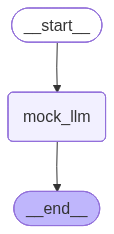

In [20]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

---

### 참고 자료

- [LangGraph 공식 문서](https://langchain-ai.github.io/langgraph/)
- [LangGraph State 가이드](https://langchain-ai.github.io/langgraph/concepts/low_level/#state)